# Estruturas de Dados Probabilísticas para Análise de Tráfego de Rede

## Bitmap · Bloom Filter · Count-Min Sketch

---

## 0. Motivação

Imagine que você é um engenheiro de redes monitorando um **link de borda** de alta velocidade.
A cada segundo chegam **100.000 pacotes**. Você precisa responder, *em tempo real*:

| Pergunta | Estrutura |
|---|---|
| "Esse IP já foi visto antes?" | **Bitmap** |
| "Esse IP está na lista negra?" | **Bloom Filter** |
| "Quais são os destinos mais frequentes?" | **Count-Min Sketch** |

Restrição: você tem apenas **alguns megabytes de RAM** para análise online.
Estruturas exatas (dicionários, conjuntos) não escalam. A solução: **sketches probabilísticos**.

> **Sketches** trocam uma pequena margem de erro por ganhos enormes em memória e velocidade.

---
## Setup — Gerando o Stream de Pacotes

Tráfego de rede real segue uma **distribuição de Zipf**: poucos destinos concentram a maioria dos pacotes (fenômeno de heavy hitters), com uma longa cauda de IPs raros.

Vamos simular **1 milhão de pacotes** com esse comportamento.

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import hashlib
import math
from collections import Counter

np.random.seed(42)

# --- Parâmetros do stream ---
N_PACOTES   = 1_000_000   # tamanho do stream
N_IPS_DIST  = 50_000      # universo de IPs de destino possíveis
ZIPF_ALPHA  = 1.3         # parâmetro de Zipf (>1); menor = mais concentrado

# Gera índices Zipf e mapeia para IPs fictícios no espaço 10.0.0.0/8
zipf_indices = np.random.zipf(ZIPF_ALPHA, N_PACOTES)
zipf_indices = np.clip(zipf_indices, 1, N_IPS_DIST)  # limita ao universo

BASE_IP = (10 << 24)  # 10.0.0.0 como inteiro
stream_ips = BASE_IP + zipf_indices  # cada pacote tem um IP destino (inteiro)

# Converte para string para visualização
def int_to_ip(n):
    return f"{(n>>24)&0xFF}.{(n>>16)&0xFF}.{(n>>8)&0xFF}.{n&0xFF}"

print(f"Stream gerado: {N_PACOTES:,} pacotes")
print(f"IPs únicos no stream: {len(set(stream_ips)):,} (de {N_IPS_DIST:,} possíveis)")
print(f"\nTop-5 destinos mais frequentes:")
for ip_int, cnt in Counter(stream_ips).most_common(5):
    print(f"  {int_to_ip(ip_int):>15}  ->  {cnt:>7,} pacotes  ({100*cnt/N_PACOTES:.1f}%)")

Stream gerado: 1,000,000 pacotes
IPs únicos no stream: 24,147 (de 50,000 possíveis)

Top-5 destinos mais frequentes:
         10.0.0.1  ->  254,150 pacotes  (25.4%)
         10.0.0.2  ->  103,675 pacotes  (10.4%)
         10.0.0.3  ->   61,327 pacotes  (6.1%)
         10.0.0.4  ->   42,378 pacotes  (4.2%)
      10.0.195.80  ->   32,945 pacotes  (3.3%)


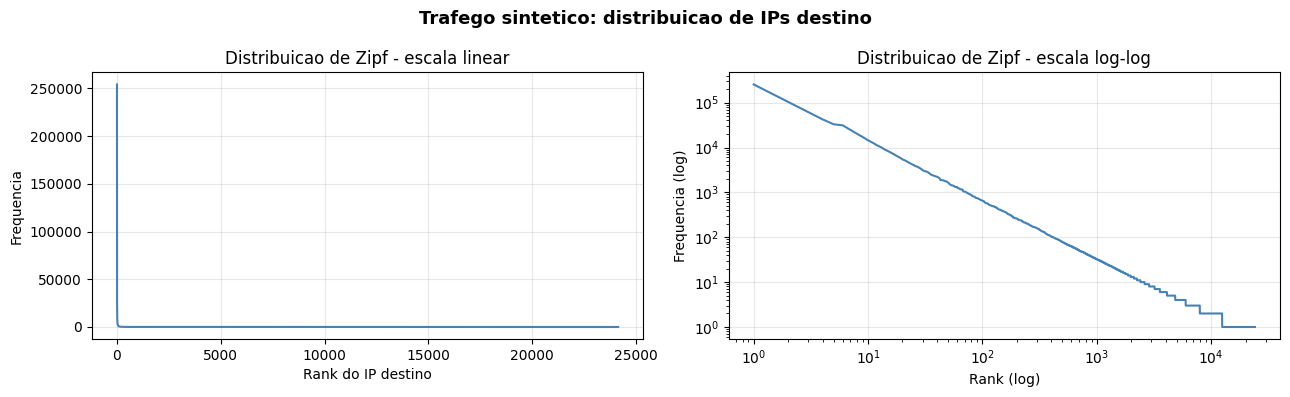

Nota: a reta em log-log e a assinatura de uma lei de potencia (Zipf).


In [16]:
# Visualização da distribuição de Zipf
contagem = Counter(stream_ips)
frequencias = sorted(contagem.values(), reverse=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(range(1, len(frequencias)+1), frequencias, color='steelblue', linewidth=1.5)
axes[0].set_xlabel('Rank do IP destino'); axes[0].set_ylabel('Frequencia')
axes[0].set_title('Distribuicao de Zipf - escala linear'); axes[0].grid(alpha=0.3)

axes[1].loglog(range(1, len(frequencias)+1), frequencias, color='steelblue', linewidth=1.5)
axes[1].set_xlabel('Rank (log)'); axes[1].set_ylabel('Frequencia (log)')
axes[1].set_title('Distribuicao de Zipf - escala log-log'); axes[1].grid(alpha=0.3)

fig.suptitle('Trafego sintetico: distribuicao de IPs destino', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("Nota: a reta em log-log e a assinatura de uma lei de potencia (Zipf).")

---
## 1. Bitmap

### Ideia

Um **bitmap** é simplesmente um array de bits onde cada posição representa um elemento do universo.

```
Universo de IPs:   0   1   2   3   4   5   6   7
Bitmap:          [ 0 | 1 | 0 | 1 | 1 | 0 | 0 | 1 ]
                       ^       ^   ^           ^
                    vistos no stream
```

- **Inserção:** `bitmap[hash(elemento)] = 1`  
- **Consulta:** `return bitmap[hash(elemento)] == 1`  
- **Sem erros** (para universos mapeados 1-para-1)  
- **Problema:** tamanho = tamanho do universo. Para IPv4 completo: **512 MB**!

### Caso de uso: detecção de IPs novos

> *"Esse IP destino já foi visto nessa janela de monitoramento?"*

In [25]:
class Bitmap:
    """
    Bitmap simples usando bytearray (8 bits por byte).
    Recebe o tamanho do universo (numero de posicoes de bit).
    """
    def __init__(self, universo: int):
        self.tamanho = universo
        # Aloca ceil(universo/8) bytes — cada byte guarda 8 bits
        self.bits = bytearray(math.ceil(universo / 8))

    def _pos(self, elemento: int):
        """Retorna (indice do byte, indice do bit dentro do byte)."""
        idx = elemento % self.tamanho
        return idx // 8, idx % 8

    def inserir(self, elemento: int):
        byte_idx, bit_idx = self._pos(elemento)
        self.bits[byte_idx] |= (1 << bit_idx)   # ativa o bit com OR

    def consultar(self, elemento: int) -> bool:
        byte_idx, bit_idx = self._pos(elemento)
        return bool(self.bits[byte_idx] & (1 << bit_idx))  # testa o bit com AND

    def memoria_bytes(self) -> int:
        return len(self.bits)


# --- Experimento: janela de 10.000 pacotes ---
JANELA = 1_000_000

# Universo restrito: apenas os IPs do nosso espaco sintetico (50k IPs)
bm = Bitmap(universo=N_IPS_DIST + 1)

novos, recorrentes = 0, 0
novos_por_pacote = []

for ip in stream_ips[:JANELA]:
    idx = ip - BASE_IP  # mapeia IP -> indice no universo
    if not bm.consultar(idx):
        bm.inserir(idx)
        novos += 1
    else:
        recorrentes += 1
    novos_por_pacote.append(novos)

print(f"Janela de {JANELA:,} pacotes processada")
print(f"  IPs novos      : {novos:,}")
print(f"  IPs recorrentes: {recorrentes:,}")
print(f"  Memoria usada  : {bm.memoria_bytes():,} bytes ({bm.memoria_bytes()/1024:.1f} KB)")
print(f"\nComparacao de tamanho:")
print(f"  Bitmap (universo={N_IPS_DIST:,}): {bm.memoria_bytes()/1024:.1f} KB")
print(f"  Set Python equivalente  : ~{novos * 28 / 1024:.0f} KB  (28 bytes/elemento)")
print(f"  Bitmap IPv4 completo    : {2**32 // 8 // 1024 // 1024} MB  <- inviavel!")

Janela de 1,000,000 pacotes processada
  IPs novos      : 24,147
  IPs recorrentes: 975,853
  Memoria usada  : 6,251 bytes (6.1 KB)

Comparacao de tamanho:
  Bitmap (universo=50,000): 6.1 KB
  Set Python equivalente  : ~660 KB  (28 bytes/elemento)
  Bitmap IPv4 completo    : 512 MB  <- inviavel!


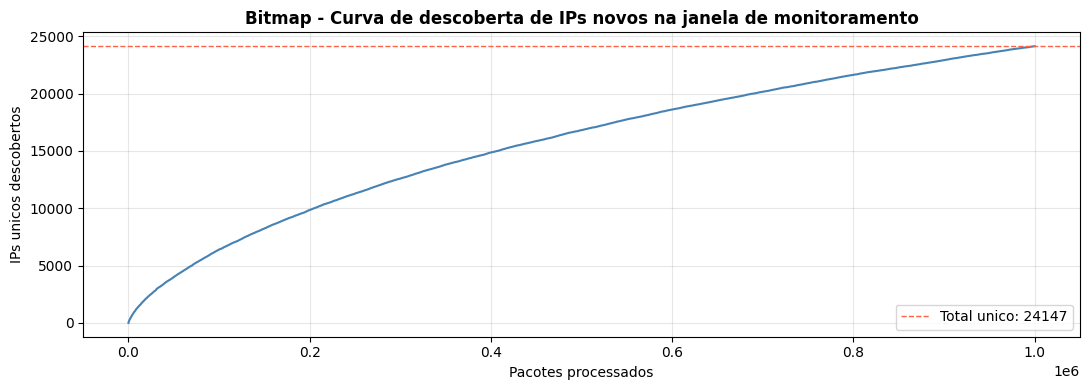

A curva desacelera progressivamente pelo efeito Zipf: os IPs mais frequentes
 são descobertos logo no início; os raros da cauda exigem muito mais pacotes para aparecer.


In [26]:
# Visualizacao: curva de descoberta de IPs novos
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(range(JANELA), novos_por_pacote, color='steelblue', linewidth=1.5)
ax.set_xlabel('Pacotes processados')
ax.set_ylabel('IPs unicos descobertos')
ax.set_title('Bitmap - Curva de descoberta de IPs novos na janela de monitoramento', fontweight='bold')
ax.grid(alpha=0.3)
ax.axhline(novos, color='tomato', linestyle='--', linewidth=1, label=f'Total unico: {novos}')
ax.legend()
plt.tight_layout()
plt.show()
print("A curva desacelera progressivamente pelo efeito Zipf: os IPs mais frequentes\n são descobertos logo no início; os raros da cauda exigem muito mais pacotes para aparecer.")

### Limitação do Bitmap

Para IPv4 completo (2^32 endereços), o bitmap precisaria de **512 MB** — inaceitável para análise online.  
E se o universo for IPv6? 2^128 posições: impossível.

**Solução:** usar múltiplas funções de hash em um bitmap *compacto* com tolerância a erros → **Bloom Filter**.

---
## 2. Bloom Filter

### Ideia

Em vez de mapear cada elemento para **uma posição única**, o Bloom Filter usa **k funções de hash** independentes, cada uma mapeando o elemento para uma posição num bitmap compacto de tamanho `m`.

```
Inserir IP_A:   hash1(A)=2 -> bit 2 = 1
                hash2(A)=5 -> bit 5 = 1
                hash3(A)=9 -> bit 9 = 1

Bitmap:  [ 0 | 0 | 1 | 0 | 0 | 1 | 0 | 0 | 0 | 1 | 0 ]
                   ^           ^               ^

Consultar IP_X: hash1(X)=2 OK  hash2(X)=5 OK  hash3(X)=7 FALHOU -> NAO ESTA
Consultar IP_A: hash1(A)=2 OK  hash2(A)=5 OK  hash3(A)=9 OK     -> PODE ESTAR
```

- **Falso negativo: impossível** — se inseriu, todos os bits estarão ativos.  
- **Falso positivo: possível** — bits ativos por outros elementos podem colidir.  
- A taxa de FP é controlável pelos parâmetros `m` (bits) e `k` (hashes).

### Fórmulas

Dado `n` elementos esperados e taxa de falso positivo desejada `p`:

```
m = - (n * ln(p)) / (ln(2))^2
k = (m/n) * ln(2)
```

### Caso de uso: blocklist de IPs maliciosos

> *"Esse IP de origem está na nossa lista negra de 100.000 endereços suspeitos?"*

In [27]:
class BloomFilter:
    """
    Bloom Filter implementado do zero com hashlib.
    Simula k funcoes de hash independentes usando MD5 com sementes diferentes.
    """
    def __init__(self, n: int, p: float):
        """
        n: numero esperado de elementos
        p: taxa de falso positivo desejada (ex: 0.01 = 1%)
        """
        # Tamanho otimo do bitmap em bits
        self.m = math.ceil(-n * math.log(p) / (math.log(2) ** 2))
        # Numero otimo de funcoes de hash
        self.k = math.ceil((self.m / n) * math.log(2))
        self.bits = bytearray(math.ceil(self.m / 8))
        self.n_inseridos = 0

    def _hashes(self, elemento: str):
        """Gera k posicoes de bit usando k sementes diferentes no MD5."""
        posicoes = []
        for semente in range(self.k):
            # Concatena semente para simular funcoes independentes
            dado = f"{semente}:{elemento}".encode()
            h = int(hashlib.md5(dado).hexdigest(), 16)
            posicoes.append(h % self.m)
        return posicoes

    def inserir(self, elemento: str):
        for pos in self._hashes(elemento):
            self.bits[pos // 8] |= (1 << (pos % 8))
        self.n_inseridos += 1

    def consultar(self, elemento: str) -> bool:
        """Retorna True se o elemento PODE estar no conjunto (possivel FP)."""
        return all(
            self.bits[pos // 8] & (1 << (pos % 8))
            for pos in self._hashes(elemento)
        )

    def fpr_teorica(self) -> float:
        """Taxa de falso positivo teorica dado o estado atual."""
        return (1 - math.exp(-self.k * self.n_inseridos / self.m)) ** self.k

    def memoria_bytes(self) -> int:
        return len(self.bits)


# --- Experimento: blocklist com 100k IPs ---
N_BLOCKLIST   = 100_000   # IPs maliciosos conhecidos
FPR_DESEJADA  = 0.01      # 1% de falso positivo

bf = BloomFilter(n=N_BLOCKLIST, p=FPR_DESEJADA)

# Gera blocklist: IPs no espaco 192.168.x.x (inteiros)
BASE_BLOCK = (192 << 24) | (168 << 16)
blocklist = set(BASE_BLOCK + i for i in range(N_BLOCKLIST))

# Insere todos no Bloom Filter
for ip in blocklist:
    bf.inserir(str(ip))

print(f"Bloom Filter configurado:")
print(f"  n (elementos esperados) : {N_BLOCKLIST:,}")
print(f"  FPR desejada            : {FPR_DESEJADA:.0%}")
print(f"  m (bits alocados)       : {bf.m:,}  ({bf.m/8/1024:.0f} KB)")
print(f"  k (funcoes de hash)     : {bf.k}")
print(f"  FPR teorica atual       : {bf.fpr_teorica():.2%}")
print(f"\nComparacao de memoria:")
print(f"  Bloom Filter            : {bf.memoria_bytes()/1024:.0f} KB")
print(f"  Set Python equivalente  : ~{N_BLOCKLIST * 28 / 1024:.0f} KB")

Bloom Filter configurado:
  n (elementos esperados) : 100,000
  FPR desejada            : 1%
  m (bits alocados)       : 958,506  (117 KB)
  k (funcoes de hash)     : 7
  FPR teorica atual       : 1.00%

Comparacao de memoria:
  Bloom Filter            : 117 KB
  Set Python equivalente  : ~2734 KB


In [28]:
# --- Validacao empirica da FPR ---
N_TESTES = 50_000
# IPs que NAO estao na blocklist (espaco 172.16.x.x)
BASE_LIMPOS = (172 << 24) | (16 << 16)
ips_limpos  = [BASE_LIMPOS + i for i in range(N_TESTES)]

falsos_positivos = sum(1 for ip in ips_limpos if bf.consultar(str(ip)))
fpr_empirica = falsos_positivos / N_TESTES

print(f"Validacao com {N_TESTES:,} IPs que NAO estao na blocklist:")
print(f"  Falsos positivos  : {falsos_positivos:,}")
print(f"  FPR empirica      : {fpr_empirica:.2%}")
print(f"  FPR teorica       : {bf.fpr_teorica():.2%}")

# Todos os itens da blocklist devem ser encontrados (sem falso negativo)
fns = sum(1 for ip in list(blocklist)[:1000] if not bf.consultar(str(ip)))
print(f"  Falsos negativos  : {fns}  <- sempre zero!")

Validacao com 50,000 IPs que NAO estao na blocklist:
  Falsos positivos  : 508
  FPR empirica      : 1.02%
  FPR teorica       : 1.00%
  Falsos negativos  : 0  <- sempre zero!


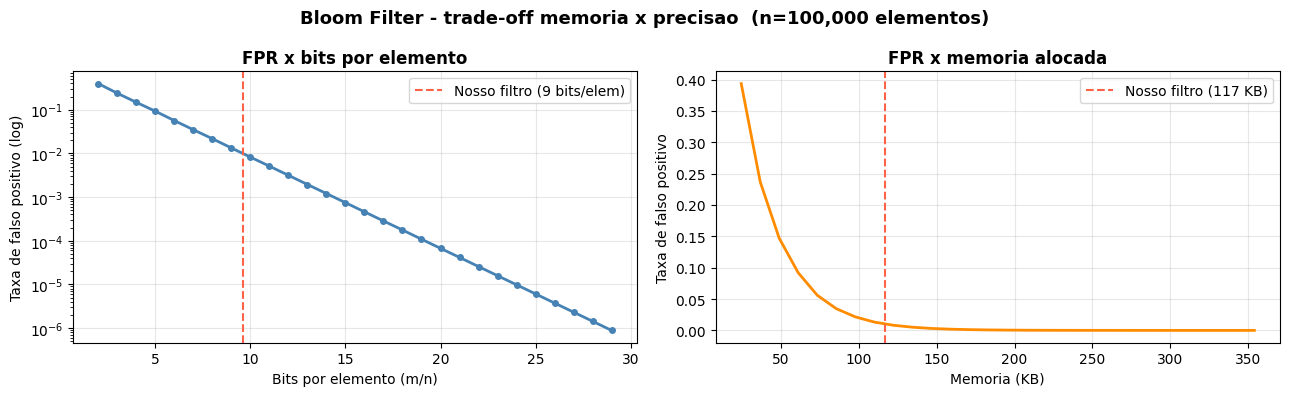

In [29]:
# --- Experimento: FPR vs tamanho do bitmap (bits por elemento) ---
bits_por_elem = np.arange(2, 30, 1)
k_otimo = lambda bpe: max(1, round(bpe * math.log(2)))
fpr_teorica_fn = lambda bpe: (1 - math.exp(-k_otimo(bpe) / bpe)) ** k_otimo(bpe)

fprs = [fpr_teorica_fn(b) for b in bits_por_elem]
memorias_kb = [N_BLOCKLIST * b / 8 / 1024 for b in bits_por_elem]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].semilogy(bits_por_elem, fprs, color='steelblue', linewidth=2, marker='o', markersize=4)
axes[0].axvline(bf.m / N_BLOCKLIST, color='tomato', linestyle='--', linewidth=1.5,
                label=f'Nosso filtro ({bf.m//N_BLOCKLIST} bits/elem)')
axes[0].set_xlabel('Bits por elemento (m/n)')
axes[0].set_ylabel('Taxa de falso positivo (log)')
axes[0].set_title('FPR x bits por elemento', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(memorias_kb, fprs, color='darkorange', linewidth=2)
axes[1].axvline(bf.memoria_bytes()/1024, color='tomato', linestyle='--', linewidth=1.5,
                label=f'Nosso filtro ({bf.memoria_bytes()//1024} KB)')
axes[1].set_xlabel('Memoria (KB)')
axes[1].set_ylabel('Taxa de falso positivo')
axes[1].set_title('FPR x memoria alocada', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

fig.suptitle(f'Bloom Filter - trade-off memoria x precisao  (n={N_BLOCKLIST:,} elementos)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Resumo do Bloom Filter

| Propriedade | Valor |
|---|---|
| Falso negativo | **Impossível** |
| Falso positivo | **Possível** (controlável) |
| Memória | Sublinear em `n` |
| Remoção de elementos | Não suportada (use Counting Bloom Filter) |

**Limitação:** o Bloom Filter só responde *existe / não existe*. E se precisarmos saber **quantas vezes** um IP aparece? → **Count-Min Sketch**.

---
## 3. Count-Min Sketch

### Ideia

O Count-Min Sketch (CMS) estende a ideia do Bloom Filter para **contagem de frequências**.  
Em vez de um vetor de bits, usa uma **matriz de contadores** com `d` linhas (funções de hash) e `w` colunas.

```
         col 0   col 1   col 2   col 3   col 4
hash_1 [   3   |   0   |   7   |   2   |   5  ]   <- linha 0
hash_2 [   0   |   5   |   1   |   8   |   3  ]   <- linha 1
hash_3 [   6   |   2   |   0   |   4   |   9  ]   <- linha 2

Inserir IP_A: incrementa hash_1(A)=2 | hash_2(A)=3 | hash_3(A)=0
Consultar IP_A: min(matriz[0][2], matriz[1][3], matriz[2][0]) = estimativa
```

- **Estimativa sempre >= valor real** (erro por excesso, nunca por falta)
- Erro máximo: `e/w` com probabilidade `1 - (1/2)^d`
- Ideal para detectar **heavy hitters** — destinos com tráfego anômalo

### Caso de uso: detecção de heavy hitters / DDoS embrionário

> *"Quais são os 5 IPs destino com maior volume de pacotes? Algum está sendo alvo de DDoS?"*

In [30]:
class CountMinSketch:
    """
    Count-Min Sketch implementado do zero.
    d linhas (depth)  -> controla a probabilidade de erro
    w colunas (width) -> controla a magnitude do erro
    """
    def __init__(self, w: int, d: int):
        self.w = w  # largura (colunas)
        self.d = d  # profundidade (linhas / funcoes de hash)
        # Matriz de contadores iniciada com zeros
        self.matriz = np.zeros((d, w), dtype=np.int64)

    def _hashes(self, elemento: str):
        """Gera d posicoes de coluna (uma por linha da matriz)."""
        posicoes = []
        for semente in range(self.d):
            dado = f"{semente}:{elemento}".encode()
            h = int(hashlib.md5(dado).hexdigest(), 16)
            posicoes.append(h % self.w)
        return posicoes

    def incrementar(self, elemento: str, valor: int = 1):
        for linha, col in enumerate(self._hashes(elemento)):
            self.matriz[linha, col] += valor

    def consultar(self, elemento: str) -> int:
        """Retorna a estimativa (minimo entre todas as linhas - dai 'Count-Min')."""
        return min(
            self.matriz[linha, col]
            for linha, col in enumerate(self._hashes(elemento))
        )

    def erro_teorico(self, n_total: int) -> float:
        """Erro aditivo esperado: (e/w) * N."""
        return (math.e / self.w) * n_total

    def memoria_bytes(self) -> int:
        return self.matriz.nbytes


# --- Parametros do CMS ---
W = 2_000   # largura: controla o erro (maior = menos erro)
D = 5       # profundidade: controla a confianca (maior = mais confianca)

cms = CountMinSketch(w=W, d=D)

# Processa o stream completo
for ip in stream_ips:
    cms.incrementar(str(ip))

print(f"Count-Min Sketch configurado:")
print(f"  w (colunas) : {W:,}")
print(f"  d (linhas)  : {D}")
print(f"  Memoria     : {cms.memoria_bytes()/1024:.1f} KB")
print(f"  Erro teorico maximo esperado: +/-{cms.erro_teorico(N_PACOTES):,.0f} pacotes")
print(f"  Probabilidade de erro dentro do limite: {1 - 0.5**D:.1%}")

# Contagem exata (referencia)
contagem_exata = Counter(stream_ips)
top10_exato = contagem_exata.most_common(10)

Count-Min Sketch configurado:
  w (colunas) : 2,000
  d (linhas)  : 5
  Memoria     : 78.1 KB
  Erro teorico maximo esperado: +/-1,359 pacotes
  Probabilidade de erro dentro do limite: 96.9%


In [31]:
# --- Comparacao: CMS vs contagem exata ---
print(f"{'IP':<18} {'Exato':>9} {'CMS':>9} {'Erro abs':>10} {'Erro %':>8}")
print("-" * 58)
erros_abs = []
for ip_int, cnt_exato in top10_exato:
    cnt_cms = cms.consultar(str(ip_int))
    erro = cnt_cms - cnt_exato
    erros_abs.append(erro)
    print(f"{int_to_ip(ip_int):<18} {cnt_exato:>9,} {cnt_cms:>9,} {erro:>+10,} {100*erro/cnt_exato:>7.2f}%")

print(f"\nErro medio absoluto (top-10): {np.mean(erros_abs):,.0f} pacotes")
print(f"Erro maximo teorico         : {cms.erro_teorico(N_PACOTES):,.0f} pacotes")

IP                     Exato       CMS   Erro abs   Erro %
----------------------------------------------------------
10.0.0.1             254,150   254,169        +19    0.01%
10.0.0.2             103,675   103,695        +20    0.02%
10.0.0.3              61,327    61,339        +12    0.02%
10.0.0.4              42,378    42,400        +22    0.05%
10.0.195.80           32,945    32,955        +10    0.03%
10.0.0.5              31,198    31,227        +29    0.09%
10.0.0.6              24,657    24,671        +14    0.06%
10.0.0.7              20,236    20,249        +13    0.06%
10.0.0.8              17,063    17,084        +21    0.12%
10.0.0.9              14,442    14,459        +17    0.12%

Erro medio absoluto (top-10): 18 pacotes
Erro maximo teorico         : 1,359 pacotes


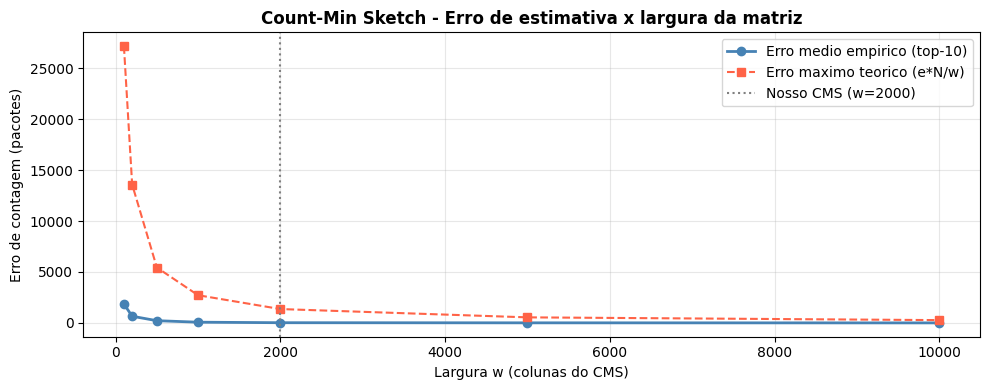

In [32]:
# --- Experimento: erro x largura da matriz ---
larguras = [100, 200, 500, 1_000, 2_000, 5_000, 10_000]
erros_medio = []

for w in larguras:
    cms_exp = CountMinSketch(w=w, d=D)
    for ip in stream_ips:
        cms_exp.incrementar(str(ip))
    erros = [cms_exp.consultar(str(ip)) - cnt for ip, cnt in top10_exato]
    erros_medio.append(np.mean(erros))

erros_teoricos = [(math.e / w) * N_PACOTES for w in larguras]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(larguras, erros_medio,    'o-', color='steelblue',  linewidth=2, label='Erro medio empirico (top-10)')
ax.plot(larguras, erros_teoricos, 's--', color='tomato',    linewidth=1.5, label='Erro maximo teorico (e*N/w)')
ax.axvline(W, color='gray', linestyle=':', linewidth=1.5, label=f'Nosso CMS (w={W})')
ax.set_xlabel('Largura w (colunas do CMS)')
ax.set_ylabel('Erro de contagem (pacotes)')
ax.set_title('Count-Min Sketch - Erro de estimativa x largura da matriz', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

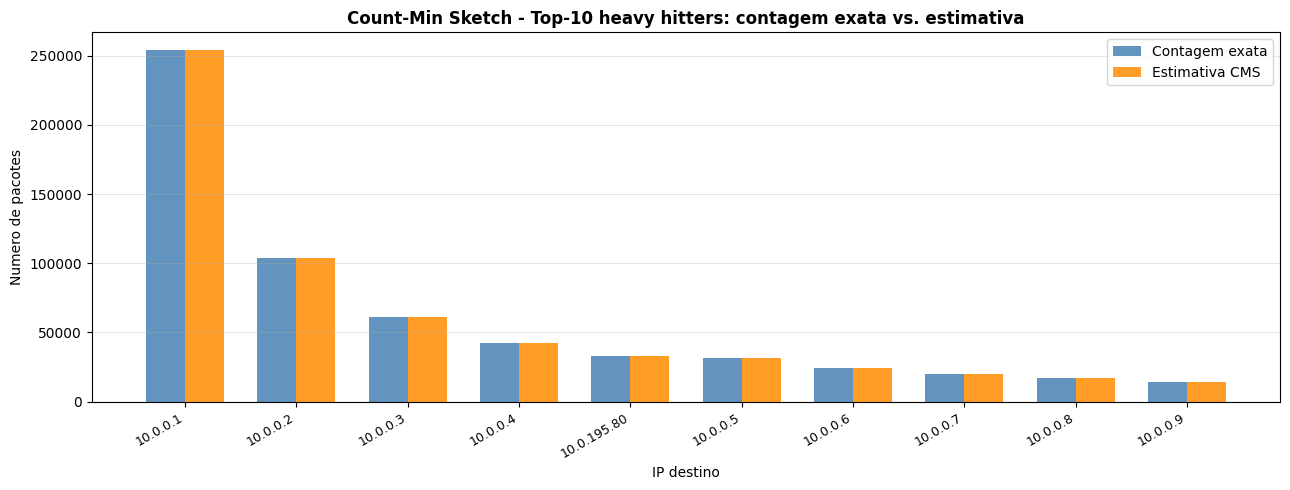

Note: CMS superestima (nunca subestima) - as barras laranja estao sempre >= azul.


In [33]:
# --- Visualizacao: top-10 heavy hitters ---
ips_labels = [int_to_ip(ip) for ip, _ in top10_exato]
cnts_exato = [cnt for _, cnt in top10_exato]
cnts_cms   = [cms.consultar(str(ip)) for ip, _ in top10_exato]

x = np.arange(len(ips_labels))
w_bar = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - w_bar/2, cnts_exato, w_bar, label='Contagem exata', color='steelblue', alpha=0.85)
ax.bar(x + w_bar/2, cnts_cms,   w_bar, label='Estimativa CMS',  color='darkorange', alpha=0.85)

ax.set_xticks(x); ax.set_xticklabels(ips_labels, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Numero de pacotes'); ax.set_xlabel('IP destino')
ax.set_title('Count-Min Sketch - Top-10 heavy hitters: contagem exata vs. estimativa', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
print("Note: CMS superestima (nunca subestima) - as barras laranja estao sempre >= azul.")

---
## 4. Comparativo Final

### As três perguntas do engenheiro de redes

| Estrutura | Pergunta respondida | Tipo de resposta | Falso Positivo | Falso Negativo | Suporta remoção |
|---|---|---|---|---|---|
| **Bitmap** | "Esse IP já apareceu?" | Exata (no domínio mapeado) | Não | Não | Sim |
| **Bloom Filter** | "Esse IP está na blocklist?" | Probabilística | Possível | Impossível | Não |
| **Count-Min Sketch** | "Quantas vezes esse IP apareceu?" | Aproximada (>= real) | — | Nunca subestima | Sim* |

*Com cuidados especiais (conservative update)

### Trade-offs de memória (nosso experimento)

| Estrutura | Parâmetros | Memória sketch | Estrutura exata equivalente |
|---|---|---|---|
| Bitmap | 50k IPs | ~6 KB | ~1,4 MB (set Python) |
| Bloom Filter | 100k IPs, FPR=1% | ~120 KB | ~2,7 MB (set Python) |
| Count-Min Sketch | w=2000, d=5 | ~78 KB | ~1,4 MB (dict Python) |

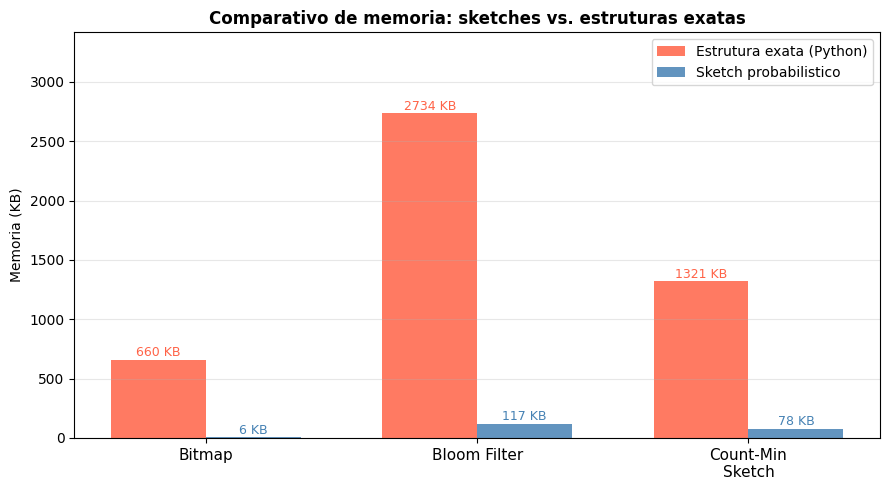

In [34]:
# --- Grafico comparativo de memoria ---
estruturas  = ['Bitmap', 'Bloom Filter', 'Count-Min\nSketch']
mem_sketch  = [bm.memoria_bytes()/1024, bf.memoria_bytes()/1024, cms.memoria_bytes()/1024]
mem_exata   = [novos * 28 / 1024, N_BLOCKLIST * 28 / 1024, len(contagem_exata) * 56 / 1024]

x = np.arange(len(estruturas))
w_bar = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - w_bar/2, mem_exata,  w_bar, label='Estrutura exata (Python)', color='tomato',    alpha=0.85)
bars2 = ax.bar(x + w_bar/2, mem_sketch, w_bar, label='Sketch probabilistico',    color='steelblue', alpha=0.85)

for i, (me, ms) in enumerate(zip(mem_exata, mem_sketch)):
    ax.text(i - w_bar/2, me + 30, f'{me:.0f} KB', ha='center', fontsize=9, color='tomato')
    ax.text(i + w_bar/2, ms + 30, f'{ms:.0f} KB', ha='center', fontsize=9, color='steelblue')

ax.set_xticks(x); ax.set_xticklabels(estruturas, fontsize=11)
ax.set_ylabel('Memoria (KB)'); ax.set_ylim(0, max(mem_exata)*1.25)
ax.set_title('Comparativo de memoria: sketches vs. estruturas exatas', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. Conclusões

Sketches probabilísticos são ferramentas essenciais quando:

1. **O stream é contínuo e imenso** — não cabe em memória processar tudo de forma exata
2. **Uma margem de erro é aceitável** — frequentemente sim em monitoramento de rede
3. **A latência importa** — todas as operações aqui são O(k) por pacote

### Onde essas estruturas aparecem na prática

| Sistema | Sketch | Para quê |
|---|---|---|
| Apache Kafka / Flink | Count-Min Sketch | Contagem de eventos em streaming |
| Redis | HyperLogLog + Bloom | Contagem de usuários únicos, cache |
| Roteadores Cisco/Juniper | Bitmap / CMS | Detecção de anomalias, NetFlow |
| Google BigTable | Bloom Filter | Evitar leituras de disco desnecessárias |
| eBPF/XDP (kernel Linux) | Bloom + CMS | Filtragem de pacotes em line-rate |

---
*Notebook didático — LPRM/Ufes*